# (17) Kyoto16: residual error look whitened?

project = ```P-VIB```, host = ```mach```, device = ```cuda:3```

**Motivation**: <br>

using this model: gaussian-sigmoid: z-256, (16, 32.0)

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 3
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:3  ———  host: mach

## Load trainer

In [3]:
a = 'gaussian_sigmoid_Kyoto16_t-16_z-[256]_u-(7,2),du-(7,3)_<grad|lin>'
b = 'b200-ep2000-lr(0.005)_beta(32:0.1)_gr(500)_(2025_03_11,23:39)'

tr, meta = load_model(f"{a}/{b}", device)
meta['checkpoint']

2000

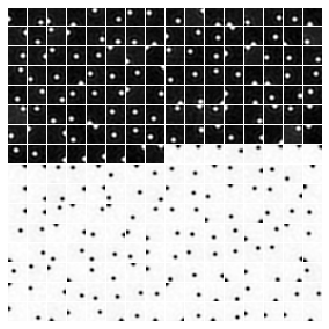

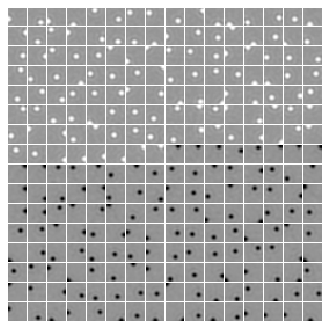

In [4]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
u1 = tonp(tr.model.layer.u_init[1].squeeze())
tr.model.show(order=np.argsort(u0), nrows=16, dpi=80)
tr.model.show(order=np.argsort(u0), nrows=16, dpi=80, method='abs-max');

In [5]:
tr.cfg.batch_size = 5000
tr.setup_data()

In [6]:
%%time

true, pred = [], []
for x, *_ in tqdm(iter(tr.dl_vld)):
    # xtract
    output = tr.model.xtract_ftr(
        feeder=tr.get_feeder(x),
        seq=range(1000),
        return_extras=['conditional'],
    ).stack()
    
    true.append(x.flatten(start_dim=1))
    conditional = output['conditional']['999']
    pred.append(conditional.loc)

del output
torch.cuda.empty_cache()
import gc
gc.collect()

true = torch.cat(true)
pred = torch.cat(pred)
error = true - pred
error.shape

100%|█████████████████████████████████████████████| 2/2 [00:52<00:00, 26.32s/it]


CPU times: user 8.58 s, sys: 2.41 s, total: 11 s
Wall time: 1min


torch.Size([9801, 256])

In [7]:
from base.dataset import make_dataset

_, whitened, _ = make_dataset('Kyoto16', device)
whitened = whitened.tensors[0].flatten(start_dim=1)
whitened.shape

torch.Size([9801, 256])

In [8]:
var = tonp(torch.var(true, dim=1))
order = np.argsort(var)[::-1]

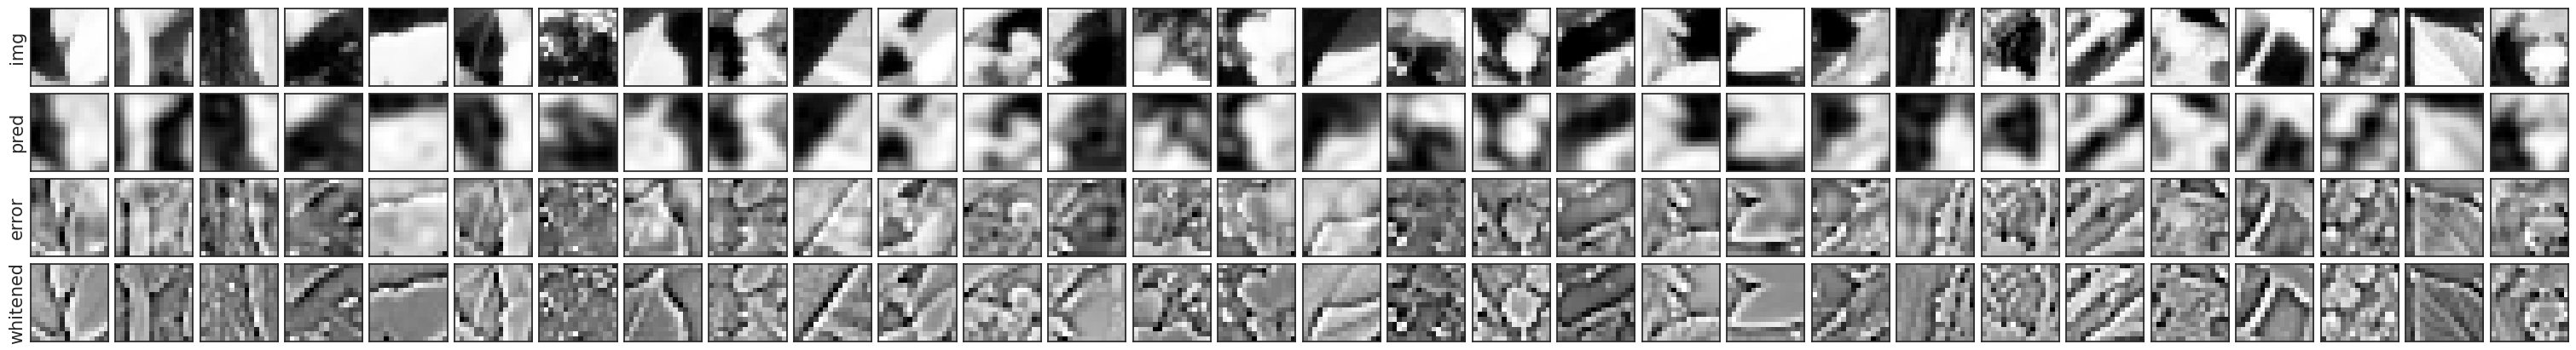

In [9]:
nrows, ncols = 4, 30
fig, axes = create_figure(nrows, ncols, (1 * ncols + 0.1, 1 * nrows), 'all', 'all')

selected_ids = np.random.choice(order[:500], size=ncols, replace=False)

for i in range(ncols):
    idx = selected_ids[i]
    axes[0, i].imshow(tonp(true[idx]).reshape(16, 16), cmap='Greys_r')
    axes[1, i].imshow(tonp(pred[idx]).reshape(16, 16), cmap='Greys_r')
    axes[2, i].imshow(tonp(error[idx]).reshape(16, 16), cmap='Greys_r')
    axes[3, i].imshow(tonp(whitened[idx]).reshape(16, 16), cmap='Greys_r')

axes[0, 0].set_ylabel('img', fontsize=15)
axes[1, 0].set_ylabel('pred', fontsize=15)
axes[2, 0].set_ylabel('error', fontsize=15)
axes[3, 0].set_ylabel('whitened', fontsize=15)

remove_ticks(axes, False)

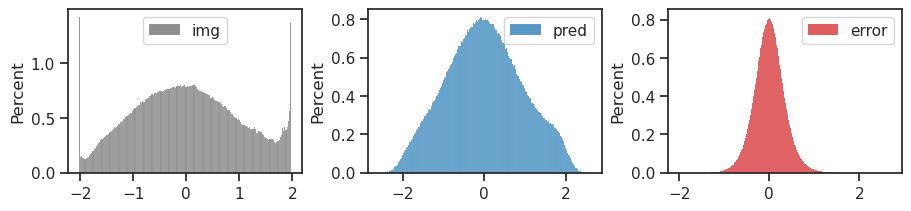

In [10]:
fig, axes = create_figure(1, 3)
sns.histplot(tonp(true).ravel(), label='img', color='dimgrey', stat='percent', ax=axes[0])
sns.histplot(tonp(pred).ravel(), label='pred', color='C0', stat='percent', ax=axes[1])
sns.histplot(tonp(error).ravel(), label='error', color='C3', stat='percent', ax=axes[2])
add_legend(axes)
plt.show()

In [11]:
def do_it(images):
    if images.ndim != 3:
        images.unsqueeze(0)
    m = images.shape[1]

    ft = torch.fft.fft2(images)
    power = torch.abs(ft) ** 2
    power_avg = power.mean(dim=0)
    
    freqs = torch.fft.fftfreq(m)  # frequencies for one dimension
    fx, fy = torch.meshgrid(freqs, freqs, indexing='ij')
    r = torch.sqrt(fx**2 + fy**2)  # radial frequency at each point
    
    r_flat = r.flatten()
    power_flat = power_avg.flatten()

    num_bins = m // 2
    bins = torch.linspace(0, r_flat.max(), num_bins + 1)
    # bucketize returns indices in 1..(num_bins+1) for each value in r_flat
    bin_inds = torch.bucketize(r_flat, bins)

    # Allocate tensors to hold the radially averaged frequency and power
    radial_freq = torch.zeros(num_bins)
    radial_power = torch.zeros(num_bins)
    
    # For each bin, compute the mean frequency and mean power
    for i in range(1, num_bins + 1):
        mask = (bin_inds == i)
        if mask.sum() > 0:
            radial_freq[i-1] = r_flat[mask].mean()
            radial_power[i-1] = power_flat[mask].mean()

    return radial_freq, radial_power

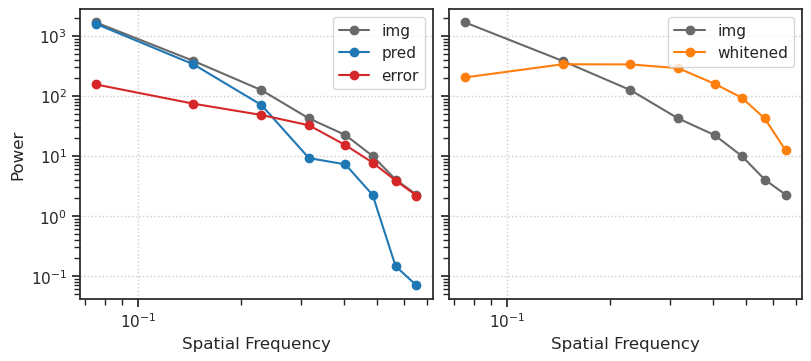

In [14]:
fig, axes = create_figure(1, 2, (8, 3.5), 'all', 'all')

# true
radial_freq, radial_power = do_it(tr.to(true.reshape(-1, 16, 16)))
axes[0].loglog(radial_freq, radial_power, label='img', color='dimgrey', marker='o')
axes[1].loglog(radial_freq, radial_power, label='img', color='dimgrey', marker='o')

# whitened
radial_freq, radial_power = do_it(tr.to(whitened.reshape(-1, 16, 16)))
axes[1].loglog(radial_freq, radial_power, label='whitened', color='C1', marker='o')

# pred
radial_freq, radial_power = do_it(tr.to(pred.reshape(-1, 16, 16)))
axes[0].loglog(radial_freq, radial_power, label='pred', color='C0', marker='o')

# error
radial_freq, radial_power = do_it(tr.to(error.reshape(-1, 16, 16)))
axes[0].loglog(radial_freq, radial_power, label='error', color='C3', marker='o')

axes[0].set(xlabel='Spatial Frequency', ylabel='Power')
axes[1].set(xlabel='Spatial Frequency')
add_legend(axes)
add_grid(axes)
plt.show()